Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter
import seaborn as sns

We define a function to parse the BED file and extract relevant metrics for each entry like distance and length

In [ ]:
def extract_fragment_data(path):
    coordinates = []

    with open(path, 'r') as f:
        for entry in f:
            fields = entry.strip().split('\t')

            # Extract binding site and fragment positions
            bs_chr, bs_start, bs_end = fields[1], int(fields[2]), int(fields[3])
            frag_chr, frag_start, frag_end = fields[7], int(fields[8]), int(fields[9])

            # Compute center positions and derived metrics
            center_bs = (bs_start + bs_end) / 2
            center_frag = (frag_start + frag_end) / 2
            dist = center_frag - center_bs
            frag_len = frag_end - frag_start

            coordinates.append((dist, frag_len))

    return pd.DataFrame(coordinates, columns=["Distance", "Length"])

In [ ]:
# Parse BED file
fragment_df = extract_fragment_data("mapped.bed")
fragment_df

,Distance,Length
0,-506.0,168
1,-506.0,152
2,-502.5,149
3,-496.0,164
4,-495.5,65
...,...,...
4336129,373.5,119
4336130,437.0,60
4336131,470.0,124
4336132,501.5,51


We group the (Fragment Length, Binding Offset) pairs to count how often each combination appears. This frequency will define the heatmap intensity.


In [ ]:
# Aggregate data
counts = fragment_df.groupby(["Distance", "Length"]).size().reset_index(name="Frequency")

# Convert to pivot table format
heatmap_matrix = counts.pivot(index="Length", columns="Distance", values="Frequency").fillna(0)


Finally, we use Matplotlib and Seaborn to render a 2D heatmap representing the V-shaped protein-DNA binding footprint.


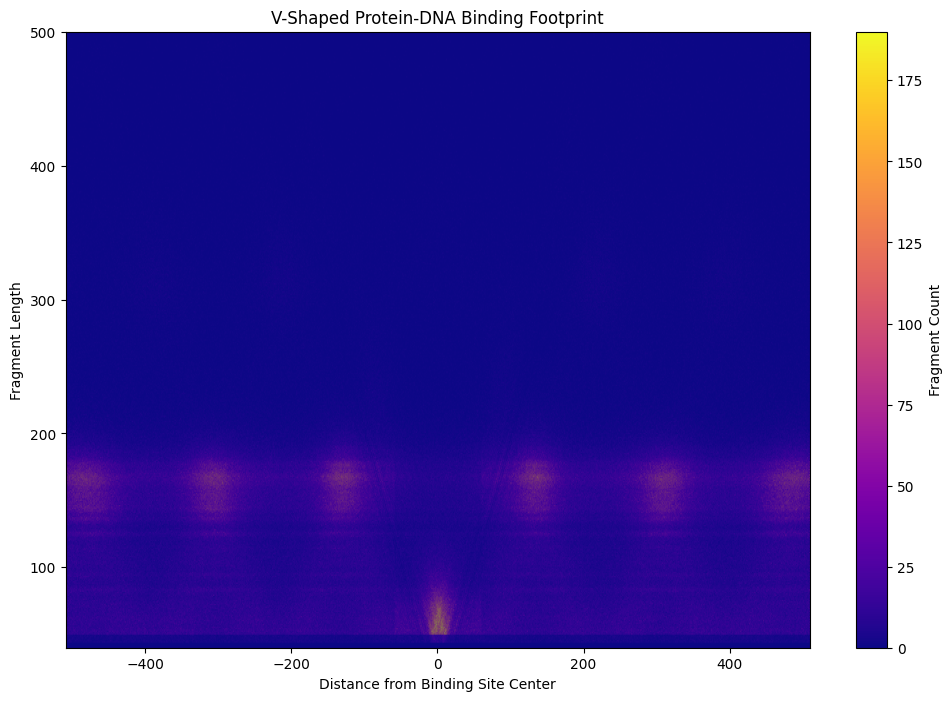

In [ ]:
# Visualization
plt.figure(figsize=(12, 8))
plt.imshow(
    heatmap_matrix.values,
    cmap='plasma',
    aspect='auto',
    extent=[
        heatmap_matrix.columns.min(),
        heatmap_matrix.columns.max(),
        heatmap_matrix.index.max(),
        heatmap_matrix.index.min()
    ]
)

plt.colorbar(label="Fragment Count")
plt.xlabel("Distance from Binding Site Center")
plt.ylabel("Fragment Length")
plt.title("V-Shaped Protein-DNA Binding Footprint")
plt.gca().invert_yaxis()
plt.show()
